<a href="https://colab.research.google.com/github/manish23454/Image_processing/blob/main/ippr_lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

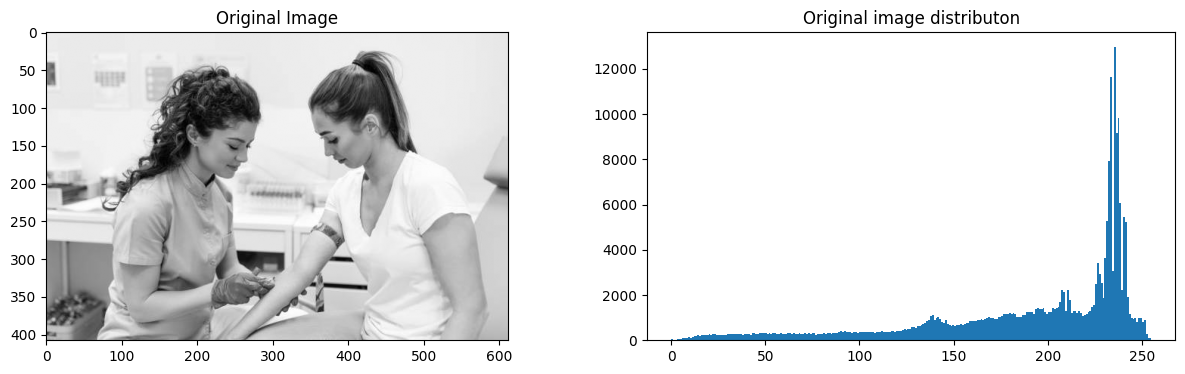

In [ ]:
#IMmporting Required Library
import cv2
import matplotlib.pyplot as plt
import numpy as np

image = cv2.imread('/content/image5.jpg',cv2.IMREAD_GRAYSCALE)
fig = plt.figure(figsize=(15,4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.imshow(image,cmap='gray')
ax1.title.set_text('Original Image')
ax2.hist(image.ravel(),bins=256)
ax2.title.set_text('Original image distributon')
plt.show()

In [ ]:
from cv2.gapi import bilateralFilter
#computing T values until difference in T is smalller that T0
T = (np.max(image)+np.min(image))/2.0 #Initial Estimate of T
T0 = 0 # Using T0 as 0 means loop breaks when T_new == T
while True:
  print(f'Thresholding Value: {T}')
  #convert image.ravel() to a numpy to a Numpy arry efficient filtering
  flat_image = image.ravel()
  #filter pixels tnto two groups
  u1_pixels = flat_image[flat_image > T]
  u2_pixels = flat_image[flat_image <= T]

  #check for empty groups to prevent zeroDivision error
  #this scenero means the threshold has pushed all pixels to an on
  #indecation convergence or an inability to finf a bimodal splin
  if len(u1_pixels) == 0 or len(u2_pixels) == 0:
    break
  #Calculate means. np.mean handles potential overflows for uint
  m1 = np.mean(u1_pixels)
  m2 = np.mean(u2_pixels)

  T_new = (m1+m2)/2.0  #use float divisionn
  if abs(T_new - T) <= T0  : # T0 is 0, so breaks when T_new == T
    break
  else:
    T = T_new
  global_thres = image > T

Thresholding Value: 127.5
Thresholding Value: 141.80345843231055
Thresholding Value: 150.77841115702745
Thresholding Value: 155.78351430637804
Thresholding Value: 157.97785163066243
Thresholding Value: 158.92760276067145
Thresholding Value: 159.40906318559848
Thresholding Value: 159.9481177464495


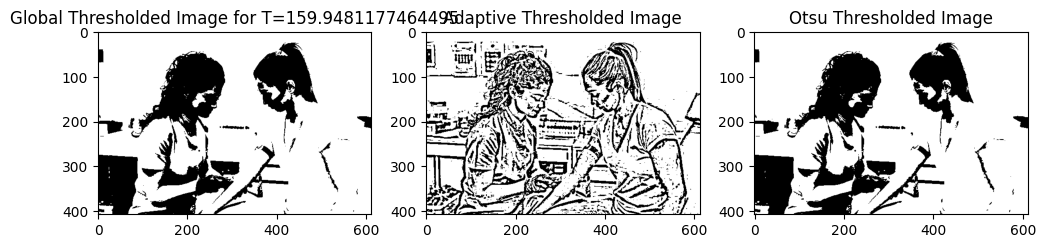

In [ ]:
#Taking Threshold Value as the mean in the neighbouthood area
#adaptive threshold(src , maxvalue ,  adapriveMethod , thresholdType , bl)
adaptive_thres = cv2.adaptiveThreshold(image,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,11,2)
#cv2 thereshold(source, theresholdValue, maxVal , thresholdingTechnique)
ret , otsu_thres = cv2.threshold(image,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

# Displaying Results of Thresholding Techniques
fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)
ax1.imshow(global_thres, cmap='gray')
ax1.title.set_text(f'Global Thresholded Image for T={T}')
ax2.imshow(adaptive_thres, cmap='gray')
ax2.title.set_text(f'Adaptive Thresholded Image')
ax3.imshow(otsu_thres, cmap='gray')
ax3.title.set_text(f'Otsu Thresholded Image')

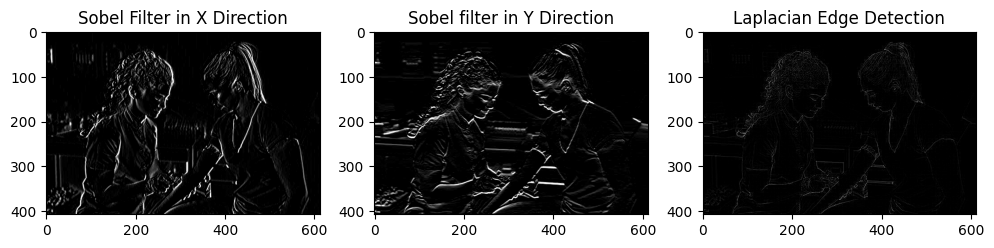

In [8]:
sobelX = cv2.Sobel(image,cv2.CV_8U,1,0,ksize=3).astype(np.uint64)
sobelY = cv2.Sobel(image,cv2.CV_8U,0,1,ksize=3).astype(np.uint64)
sobel = np.sqrt(np.power(sobelX,2) + np.power(sobelY ,2)).astype(np.uint64)

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.imshow(sobelX, cmap='gray')
ax1.title.set_text(f'Sobel Filter in X Direction')
ax2.imshow(sobelY, cmap='gray')
ax2.title.set_text(f'Sobel filter in Y Direction')
ax3.imshow(sobel, cmap='gray')
ax3.title.set_text(f'Sobel Filter Combined X ,Y')

laplacian = cv2.Laplacian(image, cv2.CV_8U)
plt.imshow(laplacian, cmap='gray')
plt.title('Laplacian Edge Detection')
plt.show()

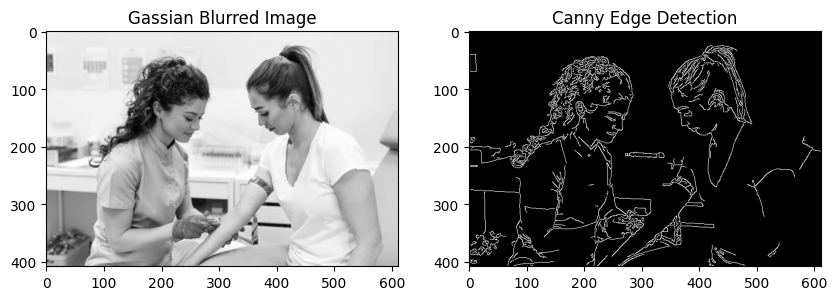

In [9]:
THRESHOLD1 = 100
THRESHOLD2 = 200
canny = cv2.Canny(image, THRESHOLD1, THRESHOLD2)
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(image, cmap='gray')
ax1.title.set_text('Gassian Blurred Image')
ax2.imshow(canny, cmap='gray')
ax2.title.set_text('Canny Edge Detection')

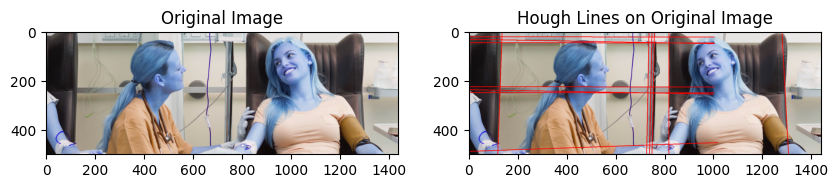

In [11]:
image = cv2.imread('/content/image4.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150, apertureSize=3)
lines = cv2.HoughLines(edges, 1, np.pi/180, 200)
for rt in lines:
  for rho, theta in rt:
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))
    cv2.line(image, (x1,y1), (x2,y2), (255,0,), 2)

fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
ax1.imshow(cv2.imread('/content/image4.jpg'))
ax1.title.set_text('Original Image')
ax2.imshow(image)
ax2.title.set_text('Hough Lines on Original Image')

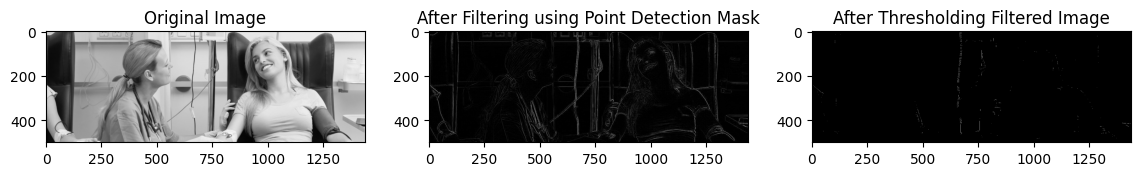

In [13]:
# Using Point Detection Mask on Image
image = cv2.imread('/content/image4.jpg', cv2.IMREAD_GRAYSCALE)
point_detection_mask = np.array([[-1,-1,-1],
[-1,8,-1],
[-1,-1,-1]])
filtered = cv2.filter2D(image, -1, point_detection_mask)

# Thresholding
T = 0.9 * np.max(filtered) # 90% of the highest absolute pixel value of the image filtered
thresh = filtered > T


# Displaying Results
fig = plt.figure(figsize=(14, 12))
ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)
ax1.imshow(image, cmap='gray')
ax1.title.set_text('Original Image')
ax2.imshow(filtered, cmap='gray')
ax2.title.set_text('After Filtering using Point Detection Mask')
ax3.imshow(thresh, cmap='gray')
ax3.title.set_text('After Thresholding Filtered Image')